## Polytope Extremes-DT example notebook

This notebook shows how to use earthkit-data and earthkit-plots to pull destination-earth data from LUMI and plot it using earthkit-plots with a specific domain.

Before running the notebook you need to set up your credentials. See the main readme of this repository for different ways to do this or use the following cells to authenticate.

You will need to generate your credentials using the desp-authentication.py script.

This can be run as follows:

In [ ]:
%%capture cap
%run ../../desp-authentication.py

This will generate a token that can then be used by earthkit and polytope.

In [ ]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]

# Requirements
To run this notebook install the following:
* pip install earthkit-data
* pip install earthkit-plots
* pip install earthkit-regrid  (Optional for spectral variables)
* pip install cf-units         (Optional for unit conversion in maps)

In [ ]:
import earthkit.data
import earthkit.plots
from earthkit.geo import regrid

In [ ]:
# Defaults to making a live data request. Set to false to use the cached GRIB file instead.
import os

LIVE_REQUEST = os.getenv("LIVE_REQUEST", "true").lower() == "true"
LIVE_REQUEST

In [ ]:
# This request matches a single parameter of the extremes DT, at 4km resolution
# which began production on 2023-12-11

request = {
        "class": "d1",
        "expver": "0001",
        "stream": "oper",
        "dataset": "extremes-dt",
        "date": "-14",
        "time": "0000",
        "type": "fc",
        "levtype": "sfc",
        "step": "0",
        "param": "167"
    }

In [ ]:
data_file = "../data/extremes-dt-earthkit-example-domain.grib"
if LIVE_REQUEST:
    data = earthkit.data.from_source("polytope", "destination-earth", request, address="polytope.lumi.apps.dte.destination-earth.eu", stream=False)
    data.to_target("file", data_file)
else:
    data = earthkit.data.from_source("file", data_file) 

In [ ]:
df = data.to_fieldlist()
df.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,2t,2026-08-20,2026-08-20,0 days,2,height_above_ground_level,None,reduced_gg


In [ ]:
# regrid to 1x1 degree
data_latlon = regrid(
    df,
    out_grid={"grid": [0.1,0.1]},
    interpolation="linear"
)

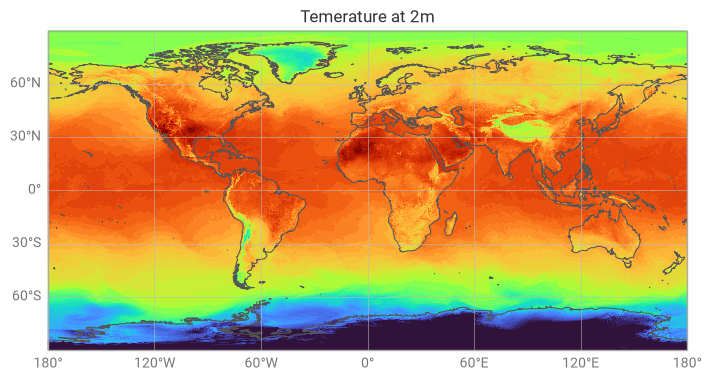

In [ ]:
chart = earthkit.plots.Map()
chart.grid_cells(
    data_latlon[0],
    colors="turbo",
    style="auto",
    units="celsius"
)

chart.title("Temerature at 2m")
chart.coastlines()
chart.gridlines()
chart.show()

Now we will plot a specific area using earthkit-plots. In this case we will plot the data we have retrieved over Europe.

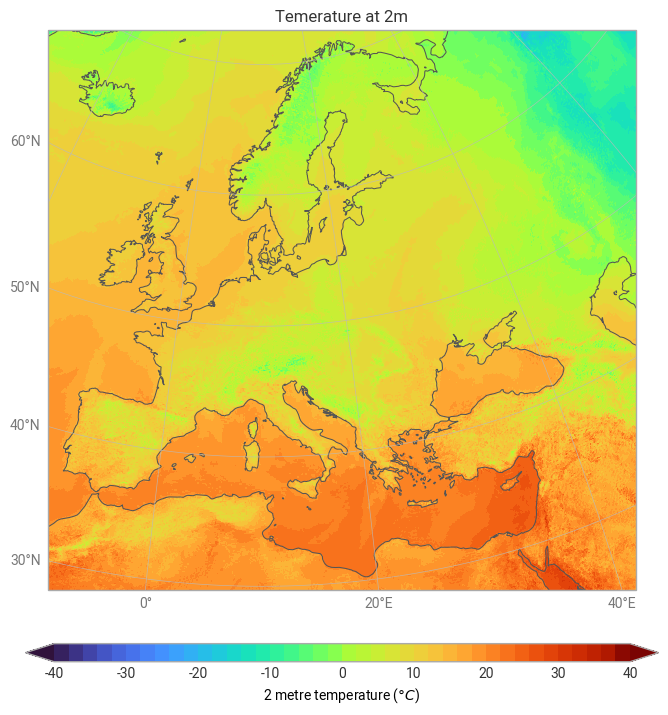

In [ ]:
chart = earthkit.plots.Map(domain="Europe")
chart.grid_cells(
    data_interpolated[0],
    colors="turbo",
    auto_style=True,
    units="celsius"
)
chart.legend()
chart.title("Temerature at 2m")
chart.coastlines()
chart.gridlines()
chart.show()